数据的基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB
None

数值列统计摘要：
              Rank         Year  Runtime (Minutes)       Rating         Votes  \
count  1000.000000  1000.000000        1

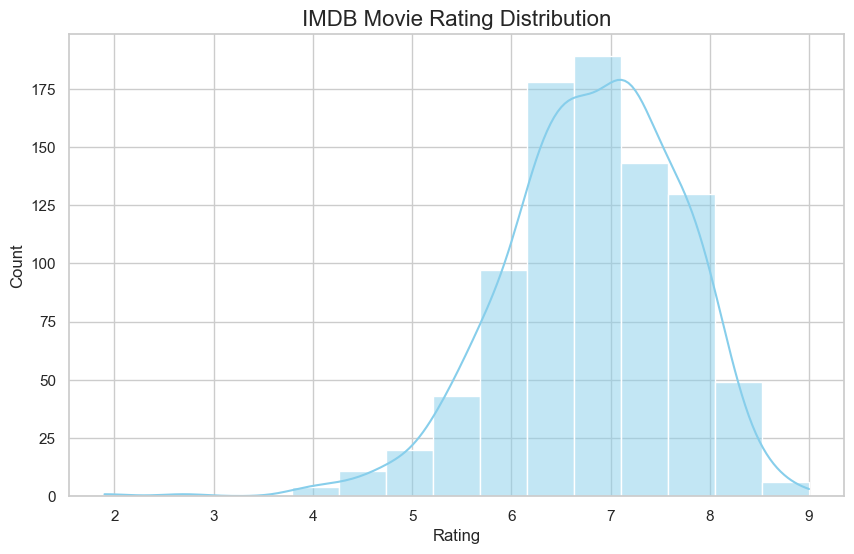


2.最受欢迎的电影类型前十名（横向条形图）


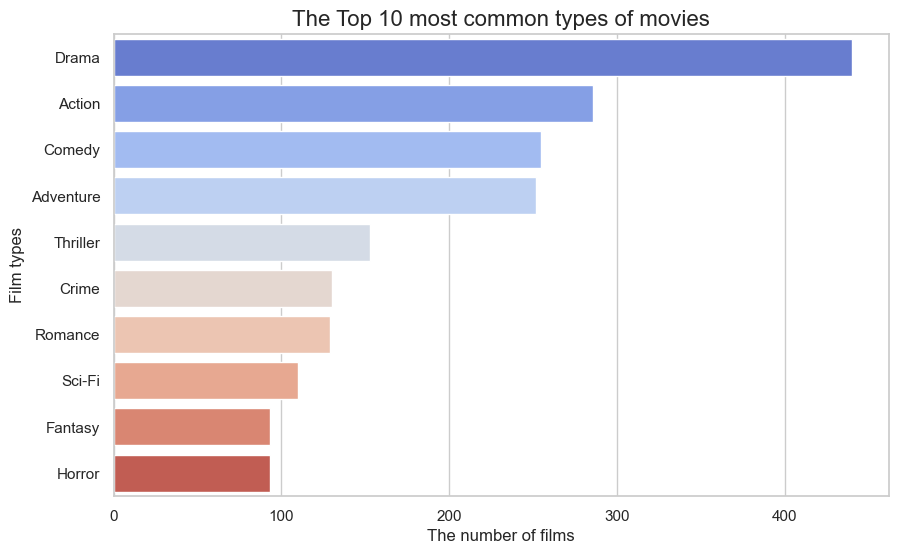


3.评分和票房之间的关系


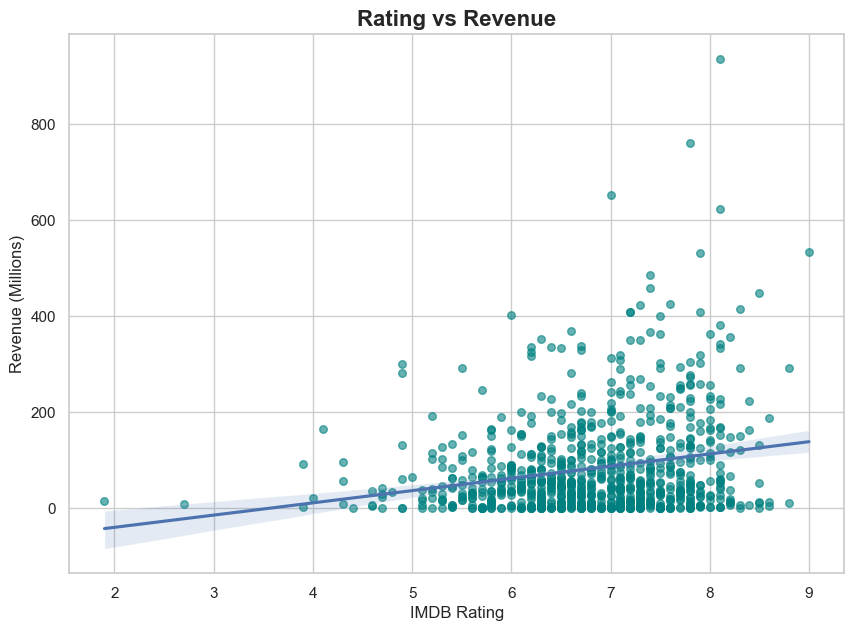

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
df=pd.read_csv('IMDB-Movie-Data.csv')
print("数据的基本信息：")
print(df.info())
print("\n数值列统计摘要：")
print(df.describe())
print("\n各列缺失值统计：")
miss_values=df.isnull().sum()
print(miss_values[miss_values>0])
print("\n删除票房缺失行")
df.dropna(subset=['Revenue (Millions)'],inplace=True)
print("\n用平均值填补Metascore的缺失值")
mean_Metascore=df['Metascore'].mean()
df['Metascore']=df['Metascore'].fillna(mean_Metascore)
print("\n清洗后的缺失值检查：")
print(df.isnull().sum().sum())
print("\n检查重复行：")
duplicates=df.duplicated().sum()
print(duplicates)
print("\n重置索引")
df.reset_index(drop=True,inplace=True)
print(f"\n清洗后数据{df.shape[0]}行，{df.shape[1]}列")
print("\n正常显示负号")
plt.rcParams['axes.unicode_minus']
print("\n设置白底灰格图标背景网格")
sns.set_theme(style="whitegrid")
print("\n1.电影评分的整体分布（直方图）")
plt.figure(figsize=(10,6))
#hist直方图，bins分组，kde平滑密度曲线
sns.histplot(df['Rating'],bins=15,kde=True,color='skyblue')
plt.title('IMDB Movie Rating Distribution',fontsize=16)
plt.xlabel('Rating',fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.show()
print("\n2.最受欢迎的电影类型前十名（横向条形图）")
#拆开Genre,统计前十
all_genres=df['Genre'].str.split(',').explode()
top_10_genres=all_genres.value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_10_genres.values,
    y=top_10_genres.index,
    hue=top_10_genres.index,
    palette='coolwarm'
    )
plt.title('The Top 10 most common types of movies',fontsize=16)
plt.xlabel('The number of films',fontsize=12)
plt.ylabel('Film types',fontsize=12)
plt.show()
print('\n3.评分和票房之间的关系')
plt.figure(figsize=(10, 7))
sns.regplot(
    x='Rating',
    y='Revenue (Millions)',
    data=df,
    scatter_kws={'alpha': 0.6, 'color': 'teal', 's': 30},
    ci=95,
    scatter=True
)
plt.title('Rating vs Revenue', fontsize=16, fontweight='bold')
plt.xlabel('IMDB Rating', fontsize=12)
plt.ylabel('Revenue (Millions)', fontsize=12)
plt.show()